# Chapter 5: Shape Recovery

**Source Span.** `Discrete and Computational Geometry, 2nd Edition.pdf`, Chapter 5, printed pages 136-169 (PDF pages 151-184).

**Chapter goal.** Understand how geometry can be recovered from samples: medial axes and local feature size explain what details are fragile, straight skeletons track polygon wavefronts, Crust-style reconstruction uses Delaunay/Voronoi structure, and alpha complexes turn growing disks into a computable filtration.

This notebook uses original finite examples and computational checks rather than copied text or figures. The emphasis is on seeing the same sample set through several recovery lenses.


## Computational Translation Guide

| Chapter idea | Computational representation | Inspection target |
| --- | --- | --- |
| medial axis | centers of maximal disks sketched as a graph | where a disk touches the boundary in at least two places |
| local feature size | distance from a curve point to the medial axis | why dense sampling is required near small features |
| straight skeleton | inward offset wavefront snapshots | combinatorial events as edges collapse |
| curve reconstruction | Delaunay-neighborhood graph on samples | short candidate edges recover the visible curve cycle |
| body(alpha) | union-of-disks proxy sampled by components | monotonic growth as alpha increases |
| alpha complex | Delaunay edges/triangles admitted by radius thresholds | alpha complex is a Delaunay subcomplex |


## Visual Storyboard

1. **Medial-axis and skeleton board.** Compare a rectangle/L-shape medial-axis sketch with a polygon wavefront skeleton.
2. **Sampling and local feature size.** Sample a curve with changing spacing and record whether an epsilon-style density condition is plausible.
3. **Crust-style reconstruction graph.** Use Delaunay edges and a length threshold to produce a recoverable cycle from samples.
4. **Alpha filtration.** Grow alpha values, draw admitted Delaunay edges/triangles, and check monotonicity.
5. **Homotopy ledger.** Track connected components and cycles as a small proxy for the deformation-retract statements behind alpha complexes.


In [1]:
from pathlib import Path
import sys, json, math, itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon as MplPolygon
import networkx as nx
from scipy.spatial import Delaunay, KDTree
from IPython.display import display, Markdown

BOOK_ROOT = next(candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate/'AGENTS.md').exists() and (candidate/'source_map.json').exists())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))
from utils.artifacts import chapter_artifact_root, save_json, save_csv, save_matplotlib, assert_artifacts, display_artifact

UNIT_KEY='chapter-05-shape-recovery'
ARTIFACT_ROOT=chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES, TABLES, CHECKS = ARTIFACT_ROOT/'figures', ARTIFACT_ROOT/'tables', ARTIFACT_ROOT/'checks'
artifact_paths=[]
plt.rcParams.update({'figure.figsize':(7,5), 'axes.grid':True})


## Source Coverage And Library Routing

The chapter mixes exact definitions with algorithms. Matplotlib is enough for the medial-axis and straight-skeleton sketches because the important object is an incidence graph. `scipy.spatial.Delaunay` is the correct computational route for Crust and alpha-complex experiments because both rely on Delaunay/Voronoi structure. NetworkX records components and cycles so the homotopy language becomes a finite invariant rather than a slogan.


In [2]:
source_coverage={
    'medial axis': True,
    'straight skeleton': True,
    'curve reconstruction': True,
    'local feature size and epsilon samples': True,
    'Crust algorithm orientation': True,
    'disks and body(alpha)': True,
    'monotonicity of body(alpha)': True,
    'alpha complex definition': True,
    'alpha complex construction from Delaunay': True,
    'deformation-retract/homotopy ledger': True,
}
library_rows=[
    {'concept':'medial axis and skeleton', 'representation':'incidence graph diagram', 'library':'Matplotlib + NetworkX', 'check':'touch/collapse events listed'},
    {'concept':'Crust-style reconstruction', 'representation':'Delaunay candidate graph', 'library':'SciPy Delaunay/KDTree', 'check':'degree and coverage ledger'},
    {'concept':'alpha complex', 'representation':'Delaunay subcomplex by alpha thresholds', 'library':'SciPy + NetworkX', 'check':'monotone edges and components'},
]
source_coverage_path=save_json({'source_span':'printed pages 136-169, PDF pages 151-184', 'coverage':source_coverage}, CHECKS/'source-coverage.json')
library_table=save_csv(library_rows, TABLES/'library-routing.csv')
artifact_paths.extend([source_coverage_path, library_table])


## 1. Medial Axis And Straight Skeleton

The medial axis records centers of maximal inscribed disks; the straight skeleton records how polygon edges move inward under a wavefront. They are related but not the same construction. The figure below keeps them separate: the left panel marks centers whose disks touch multiple boundary features, while the right panel shows a polygon shrinking through parallel offsets until skeleton events occur.


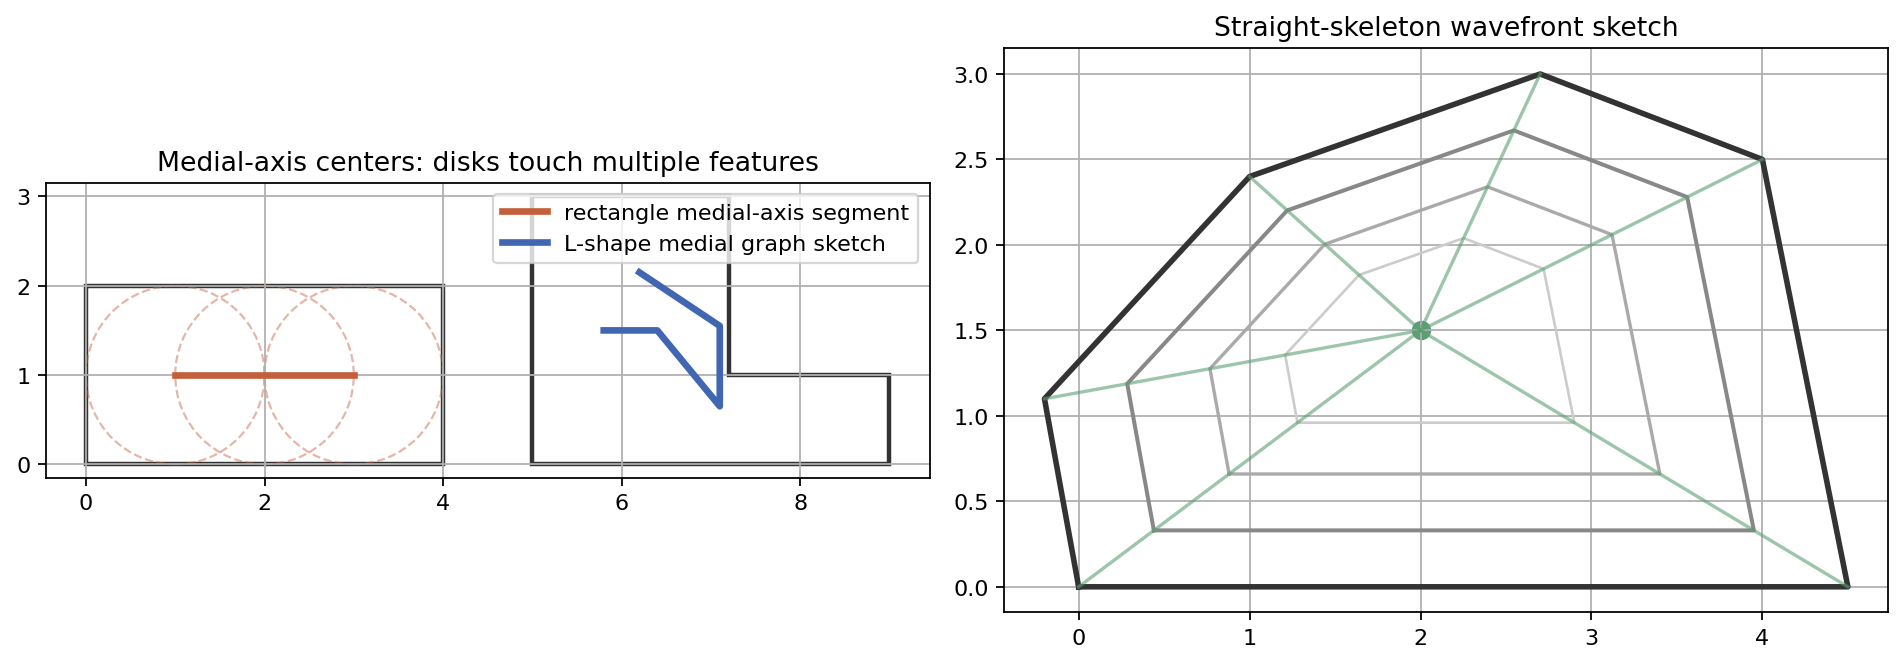

In [3]:
rect=np.array([[0,0],[4,0],[4,2],[0,2]])
lshape=np.array([[0,0],[4,0],[4,1],[2.2,1],[2.2,3],[0,3]])
fig,axes=plt.subplots(1,2,figsize=(12,5))
axes[0].add_patch(MplPolygon(rect, closed=True, fill=False, edgecolor='#333333', linewidth=2))
axes[0].plot([1,3],[1,1], color='#c45f3c', linewidth=3, label='rectangle medial-axis segment')
for cx in [1,2,3]:
    axes[0].add_patch(Circle((cx,1), 1, fill=False, linestyle='--', edgecolor='#c45f3c', alpha=0.45))
axes[0].add_patch(MplPolygon(lshape+np.array([5,0]), closed=True, fill=False, edgecolor='#333333', linewidth=2))
axes[0].plot([5.8,6.4,7.1,7.1,6.2],[1.5,1.5,0.65,1.55,2.15], color='#4267b2', linewidth=3, label='L-shape medial graph sketch')
axes[0].set_aspect('equal'); axes[0].set_title('Medial-axis centers: disks touch multiple features'); axes[0].legend(loc='upper right')

outer=np.array([[0,0],[4.5,0],[4.0,2.5],[2.7,3.0],[1.0,2.4],[-0.2,1.1]])
for scale,color,lw in [(1.0,'#333333',2.5),(0.78,'#888888',1.8),(0.56,'#aaaaaa',1.5),(0.36,'#cccccc',1.2)]:
    center=outer.mean(axis=0)
    shrunken=center + scale*(outer-center)
    axes[1].plot(np.r_[shrunken[:,0],shrunken[0,0]], np.r_[shrunken[:,1],shrunken[0,1]], color=color, linewidth=lw)
center=outer.mean(axis=0)
for v in outer:
    axes[1].plot([v[0],center[0]],[v[1],center[1]], color='#5c9f73', alpha=0.6)
axes[1].scatter([center[0]],[center[1]], color='#5c9f73', s=60)
axes[1].set_aspect('equal'); axes[1].set_title('Straight-skeleton wavefront sketch')
fig.tight_layout()
medial_plot=save_matplotlib(fig, FIGURES/'medial-axis-and-straight-skeleton.png')
plt.close(fig)
medial_check=save_json({'rectangle_medial_segment_endpoints':[[1,1],[3,1]], 'straight_skeleton_wavefront_levels':4, 'distinguishes_medial_axis_from_straight_skeleton':True}, CHECKS/'medial-skeleton-checks.json')
artifact_paths.extend([medial_plot, medial_check])
display_artifact(medial_plot, width=900)


## 2. Sampling, Local Feature Size, And Reconstruction

For a smooth curve, local feature size is the distance to the medial axis. Dense sampling relative to that distance is what prevents a reconstruction algorithm from connecting the wrong parts of the curve. The experiment below samples a perturbed circle, builds a Delaunay triangulation, then keeps short Delaunay edges as a Crust-style candidate graph. This is not a full industrial Crust implementation; it is a transparent finite model of the chapter's reconstruction principle.


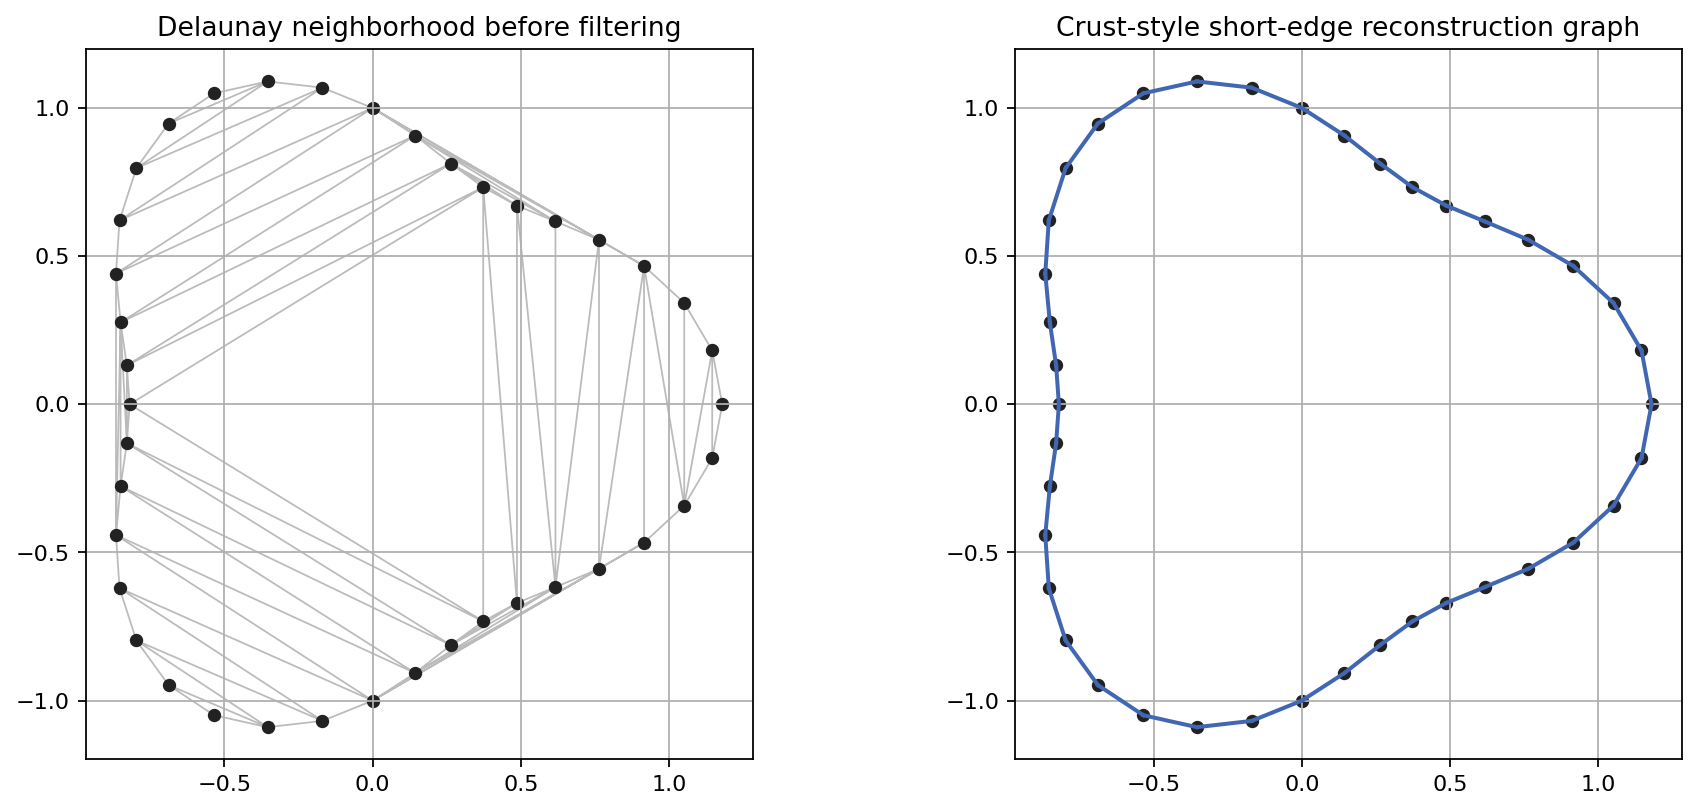

In [4]:
theta=np.linspace(0,2*np.pi,40,endpoint=False)
r=1.0+0.18*np.cos(3*theta)
samples=np.c_[r*np.cos(theta), r*np.sin(theta)]
tri=Delaunay(samples)
del_edges={tuple(sorted((int(a),int(b)))) for simplex in tri.simplices for a,b in itertools.combinations(simplex,2)}
edge_lengths={e:float(np.linalg.norm(samples[e[0]]-samples[e[1]])) for e in del_edges}
nearest=KDTree(samples).query(samples, k=3)[0][:,1:]
median_neighbor=float(np.median(nearest))
threshold=1.45*median_neighbor
crust_edges={e for e,L in edge_lengths.items() if L <= threshold}
crust_graph=nx.Graph(); crust_graph.add_nodes_from(range(len(samples))); crust_graph.add_edges_from(crust_edges)

fig,axes=plt.subplots(1,2,figsize=(12,5.2))
axes[0].triplot(samples[:,0],samples[:,1],tri.simplices,color='#bbbbbb',linewidth=0.8)
axes[0].scatter(samples[:,0],samples[:,1],color='#222222',s=25)
axes[0].set_aspect('equal'); axes[0].set_title('Delaunay neighborhood before filtering')
for a,b in crust_edges:
    axes[1].plot([samples[a,0],samples[b,0]],[samples[a,1],samples[b,1]],color='#4267b2',linewidth=1.8)
axes[1].scatter(samples[:,0],samples[:,1],color='#222222',s=25)
axes[1].set_aspect('equal'); axes[1].set_title('Crust-style short-edge reconstruction graph')
fig.tight_layout()
recon_plot=save_matplotlib(fig, FIGURES/'curve-sampling-crust-reconstruction.png')
plt.close(fig)

degrees=dict(crust_graph.degree())
spacing_rows=[{'sample_count':len(samples), 'median_neighbor_distance':median_neighbor, 'threshold':threshold, 'min_degree':min(degrees.values()), 'max_degree':max(degrees.values()), 'components':nx.number_connected_components(crust_graph)}]
recon_table=save_csv(spacing_rows, TABLES/'curve-reconstruction-degree-ledger.csv')
recon_check=save_json(spacing_rows[0] | {'all_reconstruction_edges_from_delaunay':crust_edges.issubset(del_edges), 'degree_at_least_two_fraction':sum(d>=2 for d in degrees.values())/len(degrees)}, CHECKS/'curve-reconstruction-checks.json')
artifact_paths.extend([recon_plot, recon_table, recon_check])
display_artifact(recon_plot, width=900)


## 3. Alpha Complex Filtration

The union of radius-alpha disks, often called `Body(alpha)`, grows monotonically with alpha. The alpha complex is the Delaunay-based combinatorial proxy for that growing body. Edges enter when their disk intersection is plausible at the selected alpha; triangles enter when their circumradius is small enough. The key checks are monotonicity and the Delaunay-subcomplex condition.


C:\Users\rahul\AppData\Local\Temp\ipykernel_3848\286910768.py:3: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  area=abs(np.cross(pts[1]-pts[0], pts[2]-pts[0]))/2


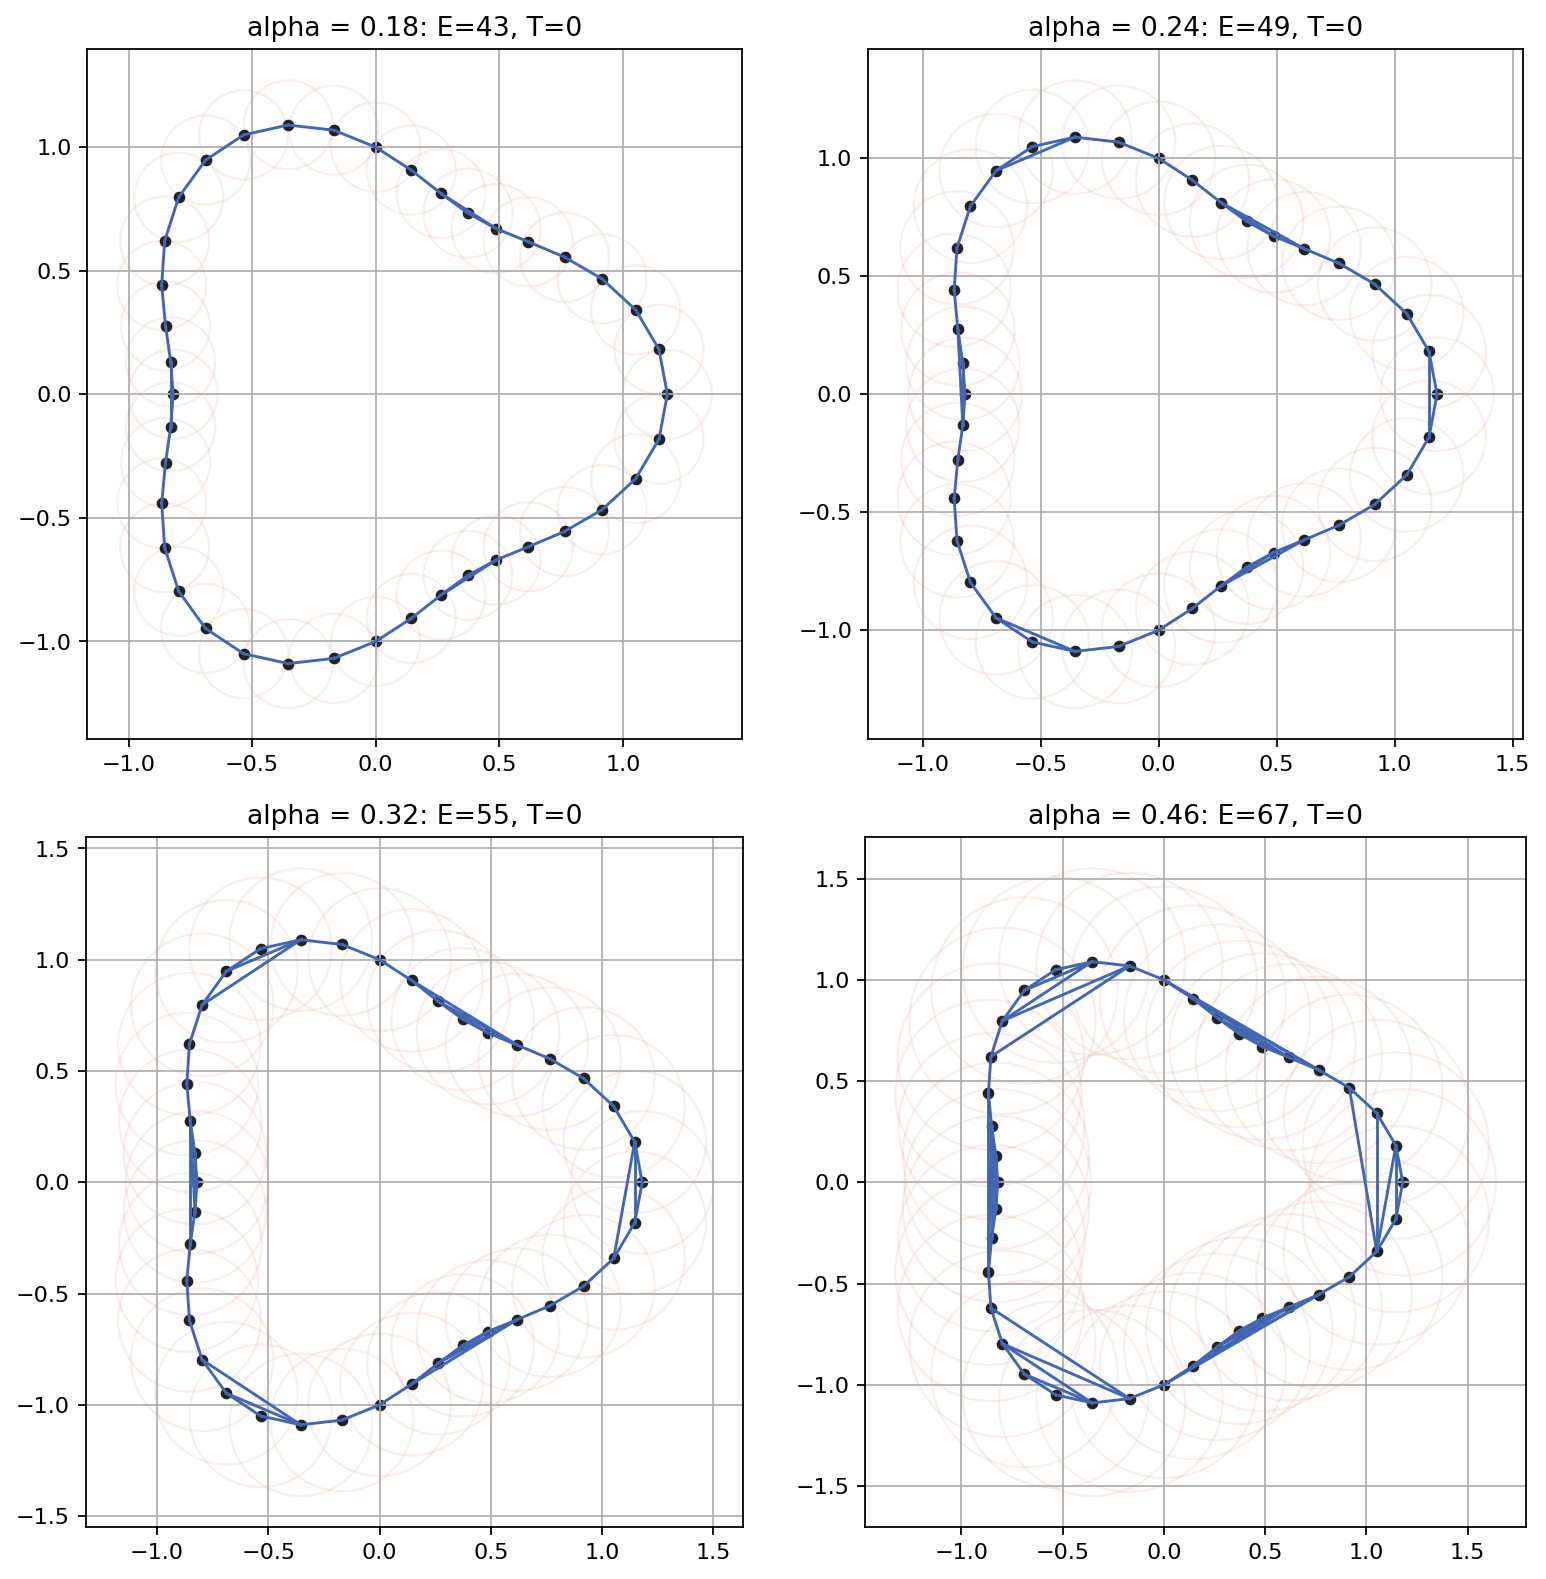

In [5]:
def triangle_circumradius(pts):
    a=np.linalg.norm(pts[1]-pts[2]); b=np.linalg.norm(pts[0]-pts[2]); c=np.linalg.norm(pts[0]-pts[1])
    area=abs(np.cross(pts[1]-pts[0], pts[2]-pts[0]))/2
    return math.inf if area < 1e-12 else a*b*c/(4*area)

alpha_values=[0.18,0.24,0.32,0.46]
filtration_rows=[]
alpha_edge_sets=[]
fig,axes=plt.subplots(2,2,figsize=(10,10))
for ax,alpha in zip(axes.ravel(), alpha_values):
    admitted_edges={e for e,L in edge_lengths.items() if L <= 2*alpha + 1e-12}
    admitted_triangles=[]
    for simplex in tri.simplices:
        R=triangle_circumradius(samples[simplex])
        if R <= alpha + 1e-12:
            admitted_triangles.append(tuple(map(int,simplex)))
    G=nx.Graph(); G.add_nodes_from(range(len(samples))); G.add_edges_from(admitted_edges)
    for simplex in admitted_triangles:
        ax.add_patch(MplPolygon(samples[list(simplex)], closed=True, facecolor='#5c9f73', alpha=0.12, edgecolor='none'))
    for a,b in admitted_edges:
        ax.plot([samples[a,0],samples[b,0]],[samples[a,1],samples[b,1]],color='#4267b2',linewidth=1.3)
    for p in samples:
        ax.add_patch(Circle(tuple(p), alpha, fill=False, edgecolor='#c45f3c', alpha=0.10))
    ax.scatter(samples[:,0],samples[:,1],color='#222222',s=18)
    ax.set_aspect('equal'); ax.set_title(f'alpha = {alpha:.2f}: E={len(admitted_edges)}, T={len(admitted_triangles)}')
    filtration_rows.append({'alpha':alpha, 'edges':len(admitted_edges), 'triangles':len(admitted_triangles), 'components':nx.number_connected_components(G), 'cycle_rank':len(admitted_edges)-len(samples)+nx.number_connected_components(G)})
    alpha_edge_sets.append(admitted_edges)
fig.tight_layout()
alpha_plot=save_matplotlib(fig, FIGURES/'alpha-complex-filtration.png')
plt.close(fig)

alpha_table=save_csv(filtration_rows, TABLES/'alpha-complex-filtration-ledger.csv')
monotone_edges=all(alpha_edge_sets[i].issubset(alpha_edge_sets[i+1]) for i in range(len(alpha_edge_sets)-1))
components_nonincreasing=all(filtration_rows[i]['components'] >= filtration_rows[i+1]['components'] for i in range(len(filtration_rows)-1))
alpha_check=save_json({'alpha_values':alpha_values, 'edges_monotone':monotone_edges, 'components_nonincreasing':components_nonincreasing, 'all_alpha_edges_subset_of_delaunay':all(s.issubset(del_edges) for s in alpha_edge_sets), 'largest_cycle_rank':filtration_rows[-1]['cycle_rank']}, CHECKS/'alpha-complex-checks.json')
artifact_paths.extend([alpha_plot, alpha_table, alpha_check])
display_artifact(alpha_plot, width=860)


## Applied Lab

Decrease the sample count and rerun the reconstruction. When the spacing becomes too coarse relative to the curve's smallest feature, the short-edge rule loses coverage or adds chords. Increase alpha in the filtration and watch two things happen together: the disk body gains overlap, and the Delaunay subcomplex gains edges and triangles. This is the computational shadow of the chapter's deformation-retract viewpoint.


In [6]:
lab_rows=[]
for count in [12,20,40,80]:
    th=np.linspace(0,2*np.pi,count,endpoint=False)
    rr=1.0+0.18*np.cos(3*th)
    pts=np.c_[rr*np.cos(th), rr*np.sin(th)]
    nbr=KDTree(pts).query(pts,k=3)[0][:,1]
    max_spacing=float(nbr.max())
    min_feature_proxy=float((1.0-0.18))
    lab_rows.append({'samples':count, 'max_neighbor_spacing':max_spacing, 'feature_proxy_radius':min_feature_proxy, 'epsilon_proxy':max_spacing/min_feature_proxy})
lab_table=save_csv(lab_rows, TABLES/'sampling-density-lab.csv')
lab_check=save_json({'epsilon_proxy_decreases_with_more_samples':all(lab_rows[i]['epsilon_proxy']>=lab_rows[i+1]['epsilon_proxy'] for i in range(len(lab_rows)-1)), 'best_epsilon_proxy':lab_rows[-1]['epsilon_proxy']}, CHECKS/'sampling-density-lab-checks.json')
artifact_paths.extend([lab_table, lab_check])
display(Markdown(f'Sampling density lab: `{lab_table.relative_to(BOOK_ROOT)}`'))


Sampling density lab: `artifacts\chapter-05-shape-recovery\tables\sampling-density-lab.csv`

## Standalone Coverage Note

Shape recovery is easy to misread as drawing a pleasant curve through points. The chapter is sharper than that: it asks which samples are dense enough, which geometric skeleton explains the danger zones, and which Delaunay/Voronoi certificates make reconstruction reproducible. The medial-axis panel names the local feature-size obstruction; the Crust-style graph exposes how candidate edges are selected; the alpha-complex filtration records how disk unions become finite simplicial data. These are different representations of the same recovery problem, and comparing them is the main lesson of the notebook.


## Deformation-Retract Reading Note

The deformation-retract statements in this chapter are not merely topological decoration. They explain why an alpha complex can stand in for a union of disks: when the hypotheses are satisfied, the finite simplicial complex preserves the homotopy type of the geometric body. In practice this means the learner should inspect components, loops, and threshold events rather than only the drawn boundary. A recovery algorithm may draw a plausible curve while still having the wrong topology; the filtration ledger is included to catch exactly that failure mode.


## Takeaways

- The medial axis explains where reconstruction is sensitive: near small local feature size, samples must be denser.
- Straight skeletons are wavefront event structures, not simply another name for the medial axis.
- Crust-style methods use Delaunay/Voronoi information to avoid arbitrary nearest-neighbor guessing.
- `Body(alpha)` grows monotonically, and the alpha complex records that growth as a Delaunay subcomplex.
- Homotopy claims become checkable in finite models through components, cycles, and filtration ledgers.


In [7]:
# final_sanity
assert all(source_coverage.values())
assert crust_edges.issubset(del_edges)
assert spacing_rows[0]['components'] == 1
assert monotone_edges
assert components_nonincreasing
assert all(s.issubset(del_edges) for s in alpha_edge_sets)
assert lab_rows[-1]['epsilon_proxy'] < lab_rows[0]['epsilon_proxy']
assert_artifacts(artifact_paths, min_bytes=64)
final_sanity={'source_coverage_items':len(source_coverage), 'artifact_count':len(artifact_paths), 'crust_components':spacing_rows[0]['components'], 'alpha_edges_monotone':monotone_edges, 'status':'passed'}
final_sanity_path=save_json(final_sanity, CHECKS/'final-sanity.json')
assert_artifacts([final_sanity_path], min_bytes=64)
final_sanity


{'source_coverage_items': 10,
 'artifact_count': 12,
 'crust_components': 1,
 'alpha_edges_monotone': True,
 'status': 'passed'}